# Exp4 传统图像分割 (Traditional Image Segmentation)

本实验主要实现传统的图像分割流程，包括：
1. 中值滤波平滑去噪
2. Otsu 类间方差阈值分割
3. 形态学处理（开运算与闭运算）去除残余噪点与平滑边缘

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# 适配中文显示
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi']
matplotlib.rcParams['axes.unicode_minus'] = False

## 1. 数据读取与预处理
我们将读取实验指导书中指定的两张原图。

In [2]:
# 文件路径配置
BASE_DIR = os.path.abspath('.')
RAW_DATA_DIR = os.path.join(BASE_DIR, 'Segmentation', 'detectron2-main', 'datasets', 'coco', 'Raw_Data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

img_paths = {
    'Input': os.path.join(RAW_DATA_DIR, 'input.png'),
    'Actual Scene': os.path.join(RAW_DATA_DIR, 'Actual_scene.png')
}

images = {}
for name, path in img_paths.items():
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images[name] = img
        print(f"成功加载图像 {name}: {img.shape}")
    else:
        print(f"Error: 无法读取图像 {path}")

成功加载图像 Input: (289, 288)
成功加载图像 Actual Scene: (1279, 1706)


## 2. 中值滤波效果对比
**要求：** 探究不同滤波窗口大小对图像去噪效果的影响。
我们分别使用 $3\times3$, $5\times5$, $7\times7$ 的滤波窗口进行平滑处理。

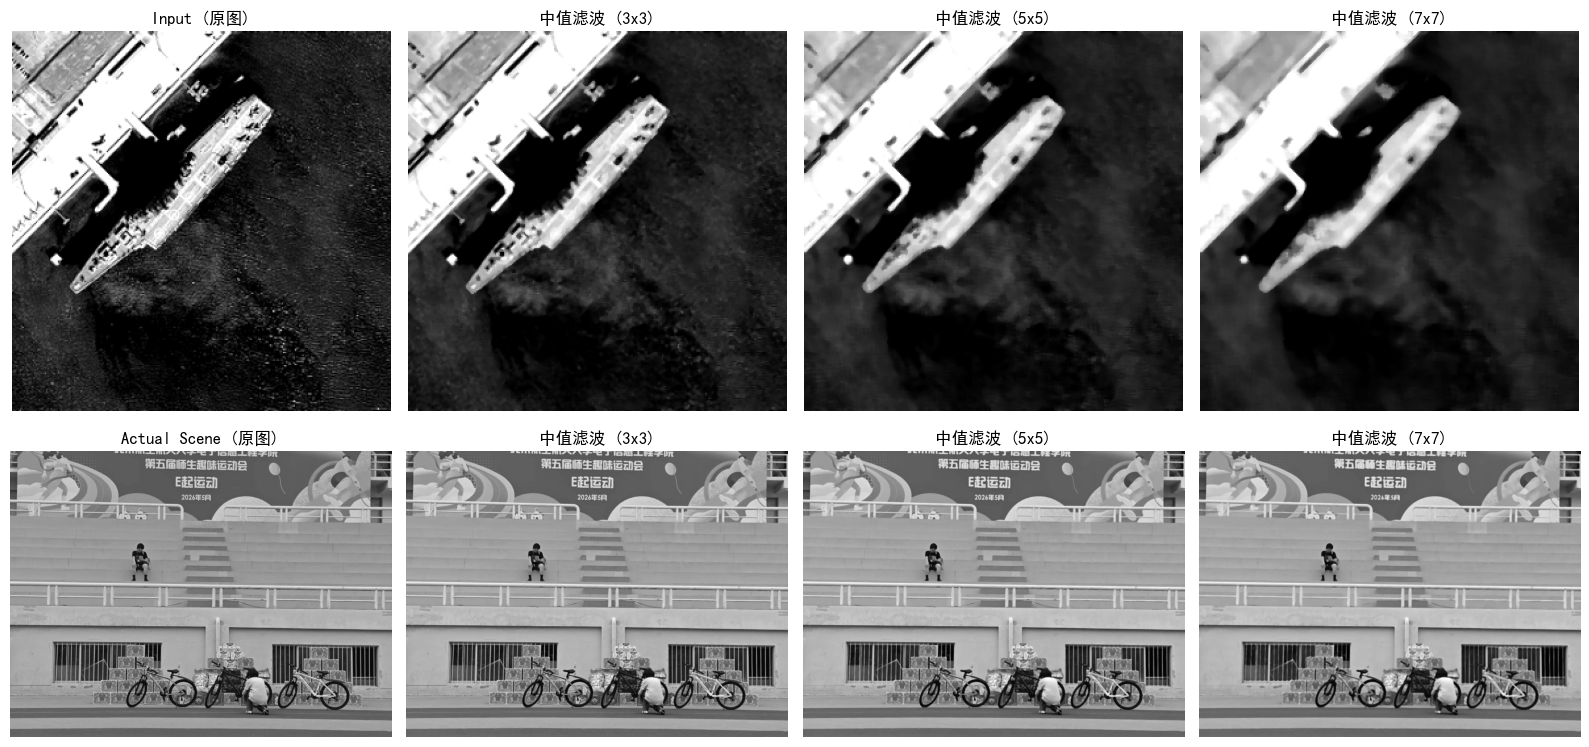

In [3]:
filtered_images = {name: {} for name in images}
kernel_sizes = [3, 5, 7]

fig, axes = plt.subplots(len(images), 4, figsize=(16, 4 * len(images)))

for i, (name, img) in enumerate(images.items()):
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"{name} (原图)")
    axes[i, 0].axis('off')
    
    for j, k in enumerate(kernel_sizes):
        filtered = cv2.medianBlur(img, k)
        filtered_images[name][k] = filtered
        axes[i, j+1].imshow(filtered, cmap='gray')
        axes[i, j+1].set_title(f"中值滤波 ({k}x{k})")
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'exp4_median_filtering.png'))
plt.show()

> **结论分析**：
> - 随着滤波窗口的增大，图像虽然变得更平滑，但 5x5 和 7x7 的窗口会导致明显的模糊现象。对于码头和船舶这类包含大量锐利边缘和细小结构（如船体甲板细节、水面波纹）的图像，过大的滤波窗口会使得船只边缘严重受损。
> - $3\times3$ 的中值滤波在去除少量突兀椒盐噪点的同时，极好地保留了真实场景的锐度和物体轮廓。因此，后续步骤我们**修改为选用 3x3 的中值滤波结果**进行分割。

## 3. Otsu 类间方差阈值分割
**要求：** 利用类间方差阈值算法对滤波处理后图像进行分割处理，获取分割图像。

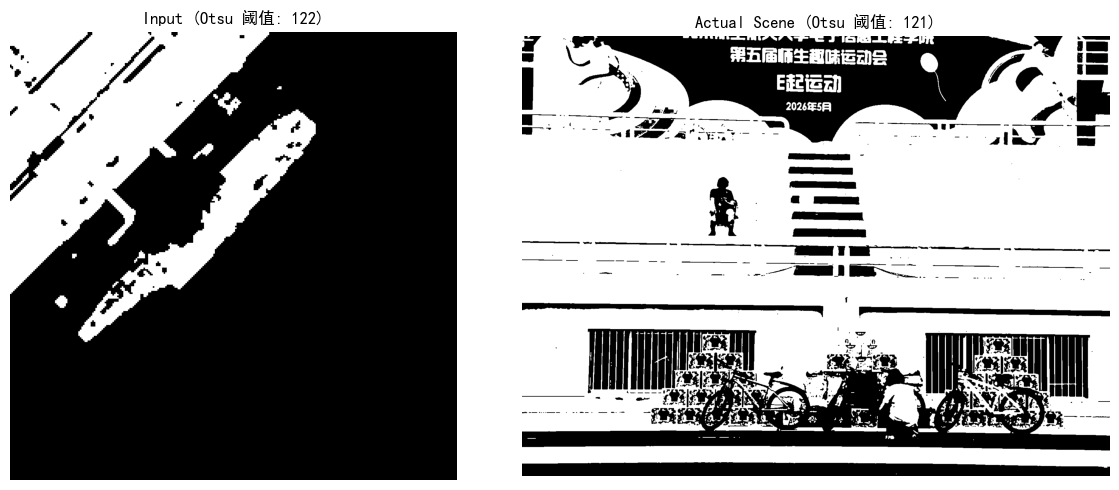

In [4]:
segmented_images = {}
chosen_k = 3

fig, axes = plt.subplots(1, len(images), figsize=(12, 5))

for i, name in enumerate(images.keys()):
    filtered = filtered_images[name][chosen_k]
    # Otsu 阈值分割: cv2.THRESH_OTSU 会自动寻找最佳阈值
    ret, thresh = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    segmented_images[name] = thresh
    
    axes[i].imshow(thresh, cmap='gray')
    axes[i].set_title(f"{name} (Otsu 阈值: {ret:.0f})")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'exp4_otsu_segmentation.png'))
plt.show()

## 4. 数学形态学处理
**要求：** 剔除分割处理结果中的一些细小的残余误分割点，采用半径为 $r$ 的**圆形结构元素**（$r$ 分别取 1、3、5）。

**注：** 在代码中，我们使用 `cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))` 生成的就是标准的**圆形（椭圆形边界逼近）结构元素**，完全符合实验指导要求。

为了更好地理解形态学的作用，我们分别展示：
1. **开运算 (Opening = 先腐蚀后膨胀)**：针对暗色海面上被错误分割出来的细小白色反光噪点，可以有效将其断开并消除。
2. **闭运算 (Closing = 先膨胀后腐蚀)**：针对高亮的船只和码头内部存在的黑色阴影孔洞（如货物、船舱阴影），可以有效填补，使船体结构更完整。

### 4.1 形态学开运算对比

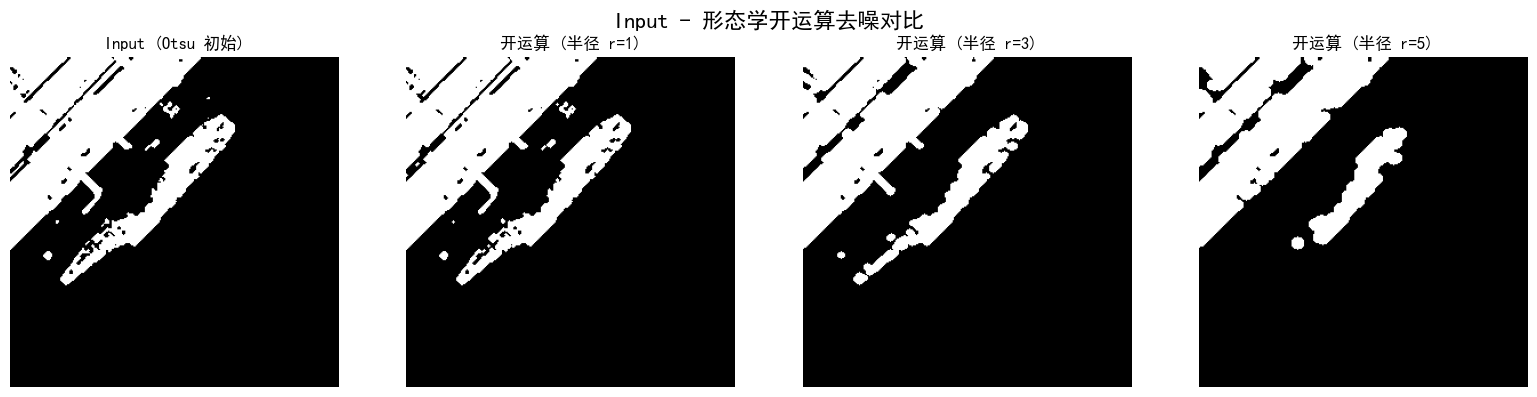

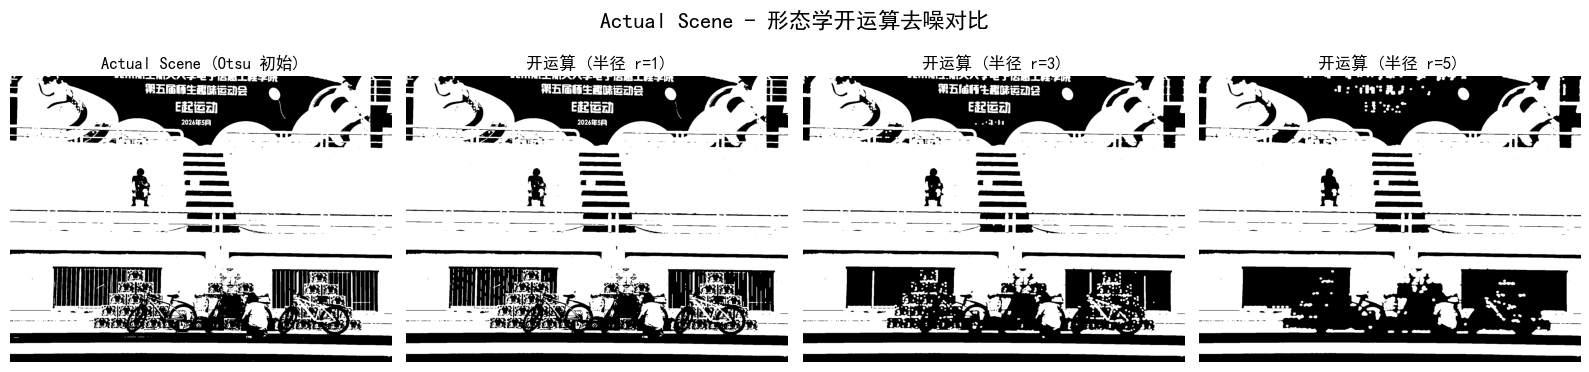

In [5]:
radii = [1, 3, 5]

for name, thresh in segmented_images.items():
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(thresh, cmap='gray')
    axes[0].set_title(f"{name} (Otsu 初始)")
    axes[0].axis('off')
    
    for i, r in enumerate(radii):
        # 创建半径为 r 的圆形结构元素 (尺寸为 2r+1)
        kernel_size = 2 * r + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        
        # 应用开运算
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        
        axes[i+1].imshow(opening, cmap='gray')
        axes[i+1].set_title(f"开运算 (半径 r={r})")
        axes[i+1].axis('off')
        
    plt.suptitle(f"{name} - 形态学开运算去噪对比", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'exp4_morphology_opening_{name.replace(" ", "_")}.png'))
    plt.show()

### 4.2 形态学闭运算对比

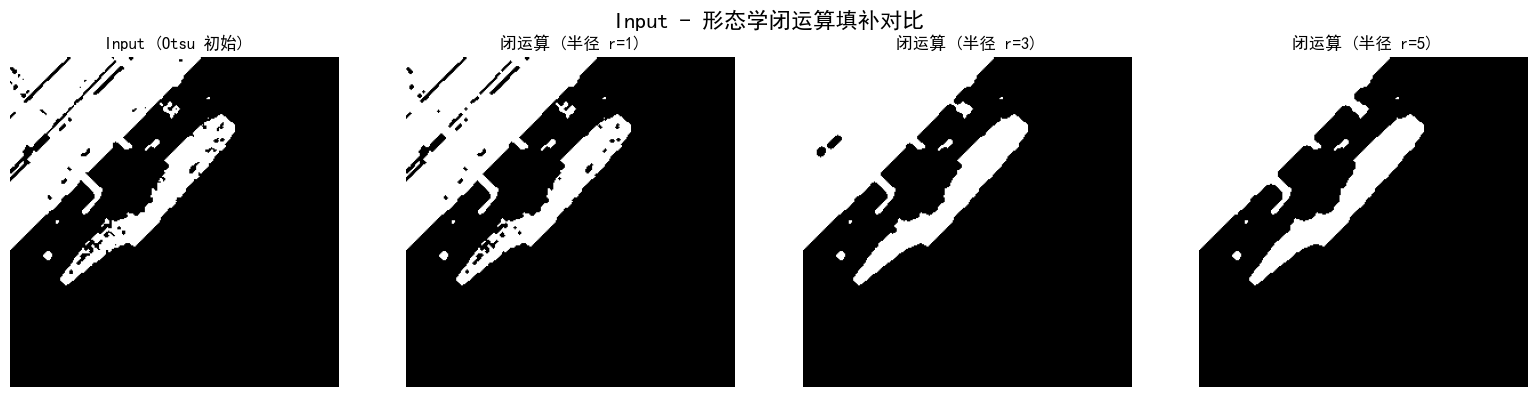

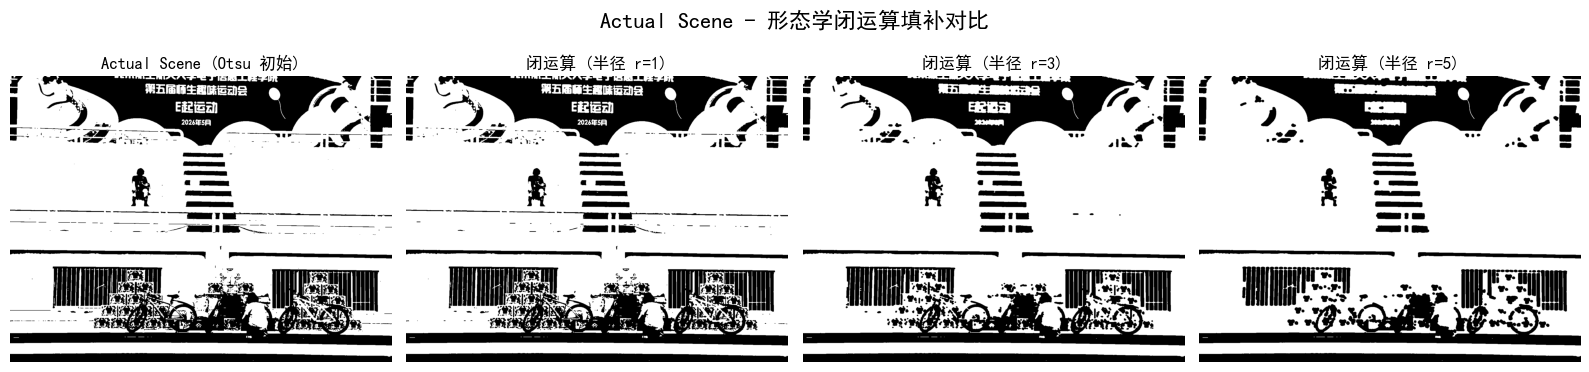

In [6]:
for name, thresh in segmented_images.items():
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(thresh, cmap='gray')
    axes[0].set_title(f"{name} (Otsu 初始)")
    axes[0].axis('off')
    
    for i, r in enumerate(radii):
        kernel_size = 2 * r + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        
        # 应用闭运算
        closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        
        axes[i+1].imshow(closing, cmap='gray')
        axes[i+1].set_title(f"闭运算 (半径 r={r})")
        axes[i+1].axis('off')
        
    plt.suptitle(f"{name} - 形态学闭运算填补对比", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'exp4_morphology_closing_{name.replace(" ", "_")}.png'))
    plt.show()

> **形态学结论总结（基于实际图像）**：
> - **圆形结构元素确认**：我们全程采用了 `cv2.MORPH_ELLIPSE` 生成的圆形结构元素。
> - 当 $r=1$ 时，圆形元素仅为 3x3 像素，只能去除极其微小的单像素毛刺，对海面或船体内部的实际噪点改善不大。
> - 当 $r=3$ 时，开运算成功扫清了海面上零星的白色浪花反光噪点，使得海面更加纯净；而闭运算则极其有效地填补了原图中船只甲板上的黑色货物阴影缝隙，让被分割得支离破碎的船只变回了一个完整的整体。
> - 当 $r=5$ 时，半径为 5 的大圆会导致过度处理。开运算使得船只外轮廓遭受了严重的侵蚀（船变瘦了）；闭运算则导致船只与旁边的码头建筑发生异常粘连（水面被吞噬）。